US HOUSING PRICE ANALYSIS USING PYTHON
--------------------------------------

Step 1: Loading Dataset

First 5 rows of the dataset:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms         Price  
0                          4.09  1.059034e+06  
1                          3.09  1.505891e+06  
2                          5.13  1.058988e+06  
3                          3.26  1.260617e+06  
4                          4.23  6.309435e+05  

Step 2: Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column      

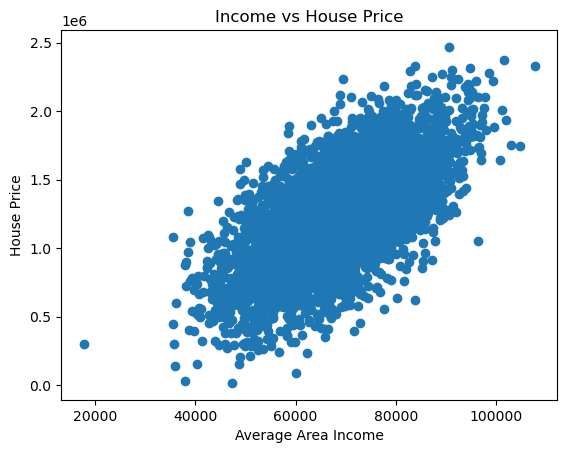

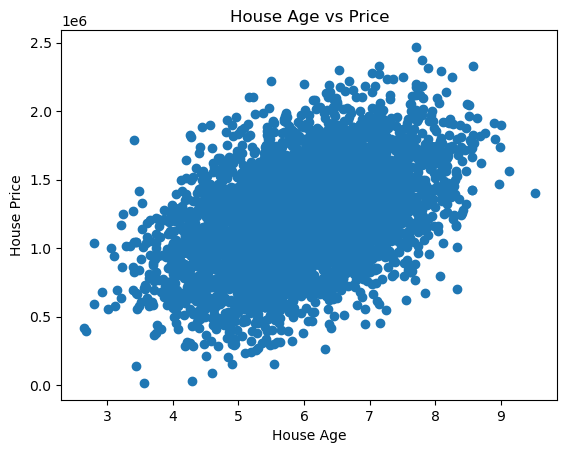

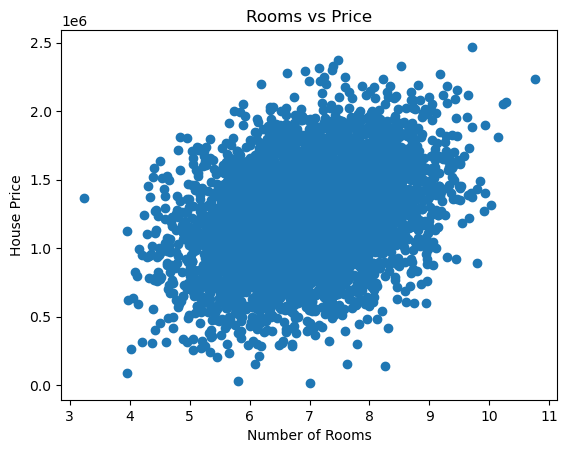

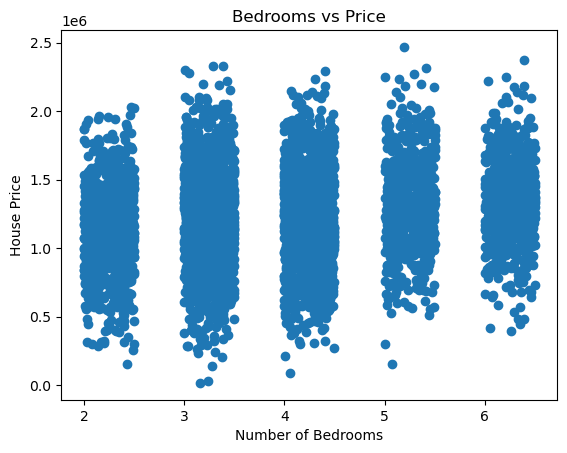


Step 5: Distribution of House Prices


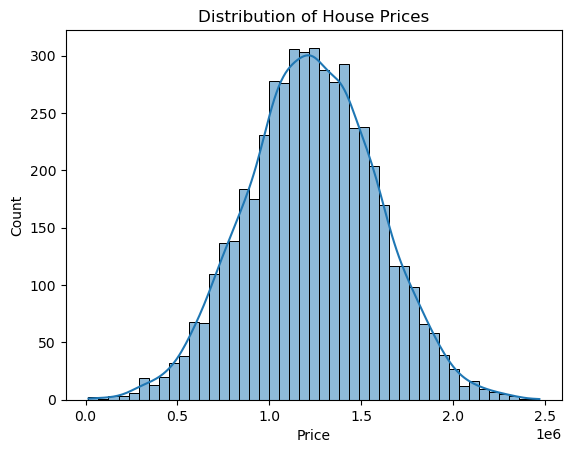


Step 6: Shapiro-Wilk Normality Test
Test Statistic: 0.9986042193997747
P-value: 0.9654192851552984
Conclusion: Data is normally distributed

Step 7: Correlation Matrix


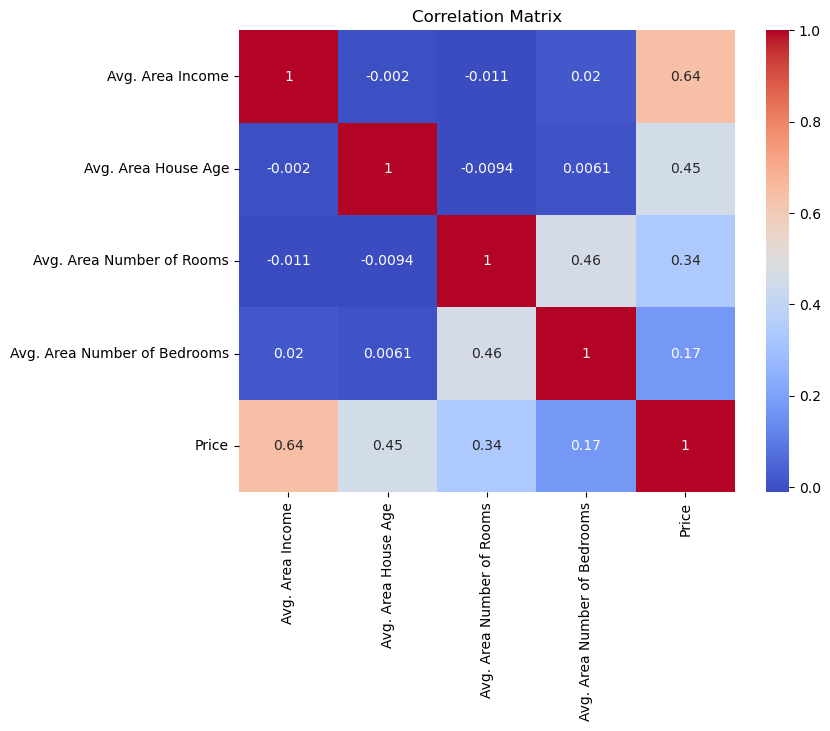


Step 8: Defining Variables

Step 9: Splitting Data into Training and Testing Sets
Training data: 4000
Testing data: 1000

Step 10: Training Linear Regression Model

Step 11: Making Predictions

Step 12: Model Evaluation
R-squared: 0.39694865194510176
RMSE: 272387.38417874585

Interpretation:
The R-squared value indicates how much variation in house prices is explained by income.

Step 13: Regression Line Visualization


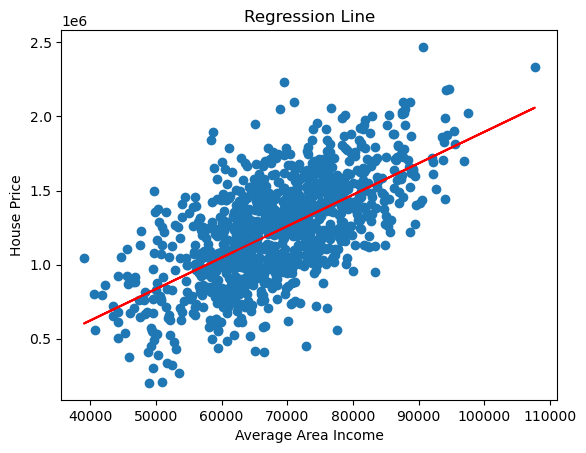


Step 14: Residual Analysis


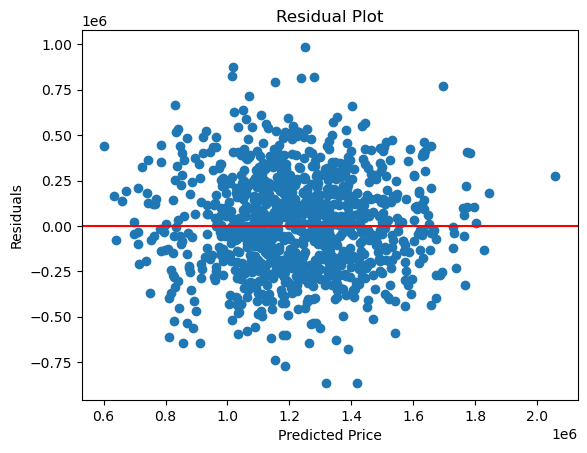


Step 15: Regression Equation
Slope (Coefficient): 21.208906292818796
Intercept: -225053.70287968707

Regression Equation:
Price = -225053.70287968707 + 21.208906292818796 * (Average Area Income)

Conclusion:
The results show a positive relationship between average area income and housing prices.
Higher income areas tend to have higher house prices.


In [10]:
# ==========================================
# US Housing Price Data Analysis
# BA Economics (Honours) Project
# Linear Regression using Python
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


print("US HOUSING PRICE ANALYSIS USING PYTHON")
print("--------------------------------------")


# -----------------------------------------
# 1. Load Dataset
# -----------------------------------------

data = pd.read_csv("/Users/apple/Downloads/Untitled spreadsheet - in.csv")

print("\nStep 1: Loading Dataset")
print("\nFirst 5 rows of the dataset:")
print(data.head())


# -----------------------------------------
# 2. Dataset Information
# -----------------------------------------

print("\nStep 2: Dataset Information")
print(data.info())

print("\nSummary Statistics")
print(data.describe())


# -----------------------------------------
# 3. Checking Missing Values
# -----------------------------------------

print("\nStep 3: Checking Missing Values")
print(data.isnull().sum())


# -----------------------------------------
# 4. Scatter Plot Analysis
# -----------------------------------------

print("\nStep 4: Scatter Plot Analysis")

plt.figure()
plt.scatter(data['Avg. Area Income'], data['Price'])
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Income vs House Price")
plt.show()


plt.figure()
plt.scatter(data['Avg. Area House Age'], data['Price'])
plt.xlabel("House Age")
plt.ylabel("House Price")
plt.title("House Age vs Price")
plt.show()


plt.figure()
plt.scatter(data['Avg. Area Number of Rooms'], data['Price'])
plt.xlabel("Number of Rooms")
plt.ylabel("House Price")
plt.title("Rooms vs Price")
plt.show()


plt.figure()
plt.scatter(data['Avg. Area Number of Bedrooms'], data['Price'])
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")
plt.title("Bedrooms vs Price")
plt.show()


# -----------------------------------------
# 5. Distribution of House Prices
# -----------------------------------------

print("\nStep 5: Distribution of House Prices")

plt.figure()
sns.histplot(data['Price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()


# -----------------------------------------
# 6. Normality Test
# -----------------------------------------

print("\nStep 6: Shapiro-Wilk Normality Test")

sample_data = data['Price'].sample(500)

stat, p = shapiro(sample_data)

print("Test Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Conclusion: Data is normally distributed")
else:
    print("Conclusion: Data is NOT normally distributed")


# -----------------------------------------
# 7. Correlation Matrix
# -----------------------------------------

print("\nStep 7: Correlation Matrix")

corr = data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# -----------------------------------------
# 8. Define Variables
# -----------------------------------------

print("\nStep 8: Defining Variables")

X = data[['Avg. Area Income']]
y = data['Price']


# -----------------------------------------
# 9. Train-Test Split
# -----------------------------------------

print("\nStep 9: Splitting Data into Training and Testing Sets")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))


# -----------------------------------------
# 10. Linear Regression Model
# -----------------------------------------

print("\nStep 10: Training Linear Regression Model")

model = LinearRegression()

model.fit(X_train, y_train)


# -----------------------------------------
# 11. Predictions
# -----------------------------------------

print("\nStep 11: Making Predictions")

predictions = model.predict(X_test)


# -----------------------------------------
# 12. Model Evaluation
# -----------------------------------------

print("\nStep 12: Model Evaluation")

r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("R-squared:", r2)
print("RMSE:", rmse)

print("\nInterpretation:")
print("The R-squared value indicates how much variation in house prices is explained by income.")


# -----------------------------------------
# 13. Regression Line
# -----------------------------------------

print("\nStep 13: Regression Line Visualization")

plt.figure()

plt.scatter(X_test, y_test)

plt.plot(X_test, predictions, color='red')

plt.xlabel("Average Area Income")
plt.ylabel("House Price")

plt.title("Regression Line")

plt.show()


# -----------------------------------------
# 14. Residual Plot
# -----------------------------------------

print("\nStep 14: Residual Analysis")

residuals = y_test - predictions

plt.figure()

plt.scatter(predictions, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()


# -----------------------------------------
# 15. Regression Equation
# -----------------------------------------

print("\nStep 15: Regression Equation")

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (Coefficient):", slope)
print("Intercept:", intercept)

print("\nRegression Equation:")
print(f"Price = {intercept} + {slope} * (Average Area Income)")


# -----------------------------------------
# Final Conclusion
# -----------------------------------------

print("\nConclusion:")
print("The results show a positive relationship between average area income and housing prices.")
print("Higher income areas tend to have higher house prices.")